# Pima Indians Diabetes - Notebook Version

This notebook runs the same logic as `pima_analysis.py` but is organized for interactive execution.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [2]:
TARGET_COL = "Outcome"
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
RANDOM_STATE = 42
DATA_PATH = "data/diabetes.csv"


In [3]:
def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Data file not found: {path}. Put Kaggle diabetes.csv there or update DATA_PATH."
        )
    return pd.read_csv(path)


def replace_zeros_with_nan(df: pd.DataFrame, columns) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)
    return df


def build_pipeline(model, scale: bool) -> Pipeline:
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


def get_score_vector(model, x_test: pd.DataFrame):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x_test)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x_test)
    return None


def evaluate_model(name: str, pipeline: Pipeline, x_train, x_test, y_train, y_test) -> dict:
    pipeline.fit(x_train, y_train)
    preds = pipeline.predict(x_test)
    scores = get_score_vector(pipeline, x_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    }
    if scores is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, scores)

    print(f"\n== {name} ==")
    print(classification_report(y_test, preds, zero_division=0))
    print(metrics)
    return metrics


def cross_validate_auc(name: str, pipeline: Pipeline, x, y) -> None:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    try:
        auc_scores = cross_val_score(pipeline, x, y, scoring="roc_auc", cv=cv)
        print(f"{name} CV AUC: mean={auc_scores.mean():.4f} std={auc_scores.std():.4f}")
    except Exception as exc:
        print(f"{name} CV AUC failed: {exc}")


def plot_basic_eda(df: pd.DataFrame, target_col: str) -> None:
    sns.set_theme(style="whitegrid")
    numeric = df.select_dtypes(include=[np.number])

    if target_col in df.columns:
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.countplot(x=target_col, data=df, ax=ax)
        ax.set_title("Target distribution")
        fig.tight_layout()
        plt.show()

    missing = df.isna().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        fig, ax = plt.subplots(figsize=(6, 4))
        missing.sort_values(ascending=False).plot(kind="bar", ax=ax)
        ax.set_title("Missing values per column")
        fig.tight_layout()
        plt.show()

    feature_cols = [c for c in numeric.columns if c != target_col]
    if feature_cols:
        df[feature_cols].hist(bins=20, figsize=(12, 8))
        plt.tight_layout()
        plt.show()

    if feature_cols and target_col in df.columns:
        ncols = 3
        nrows = int(np.ceil(len(feature_cols) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)
        for idx, col in enumerate(feature_cols):
            row = idx // ncols
            col_idx = idx % ncols
            sns.boxplot(x=target_col, y=col, data=df, ax=axes[row][col_idx])
        for idx in range(len(feature_cols), nrows * ncols):
            row = idx // ncols
            col_idx = idx % ncols
            axes[row][col_idx].axis("off")
        fig.tight_layout()
        plt.show()

    if numeric.shape[1] > 1:
        corr = numeric.corr()
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Feature correlation")
        fig.tight_layout()
        plt.show()


Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Zero counts (treated as missing): {'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11}
Missing values after replacement:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


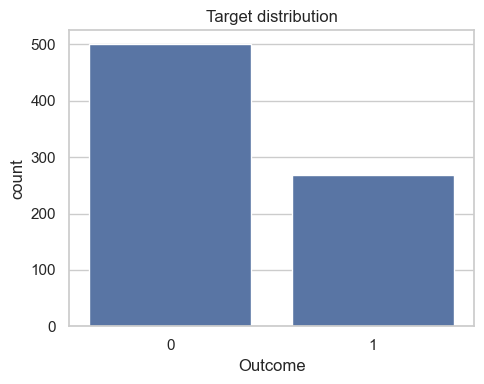

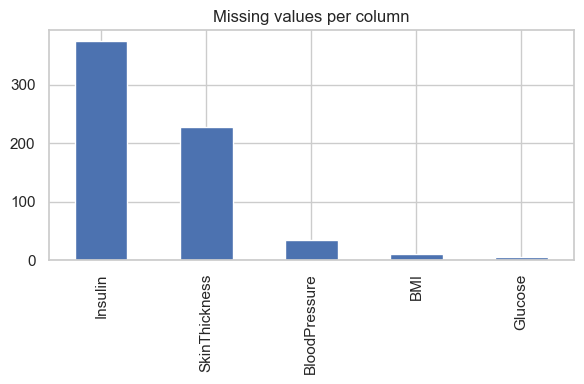

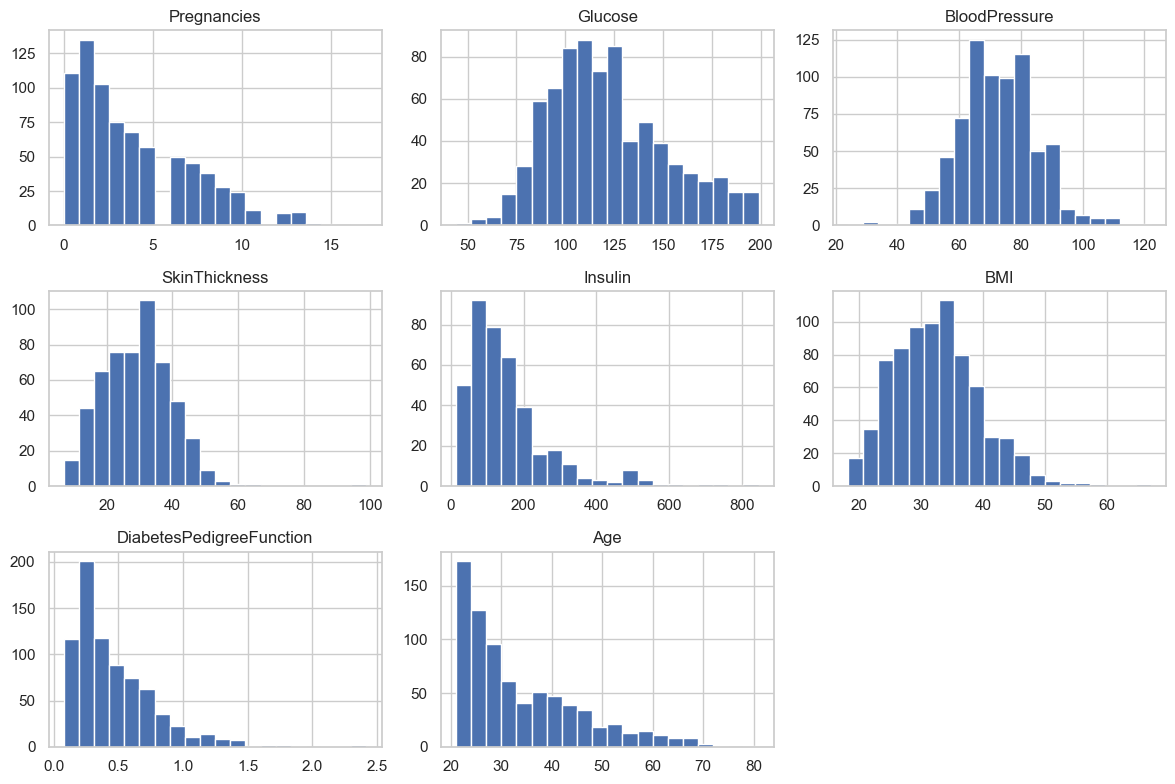

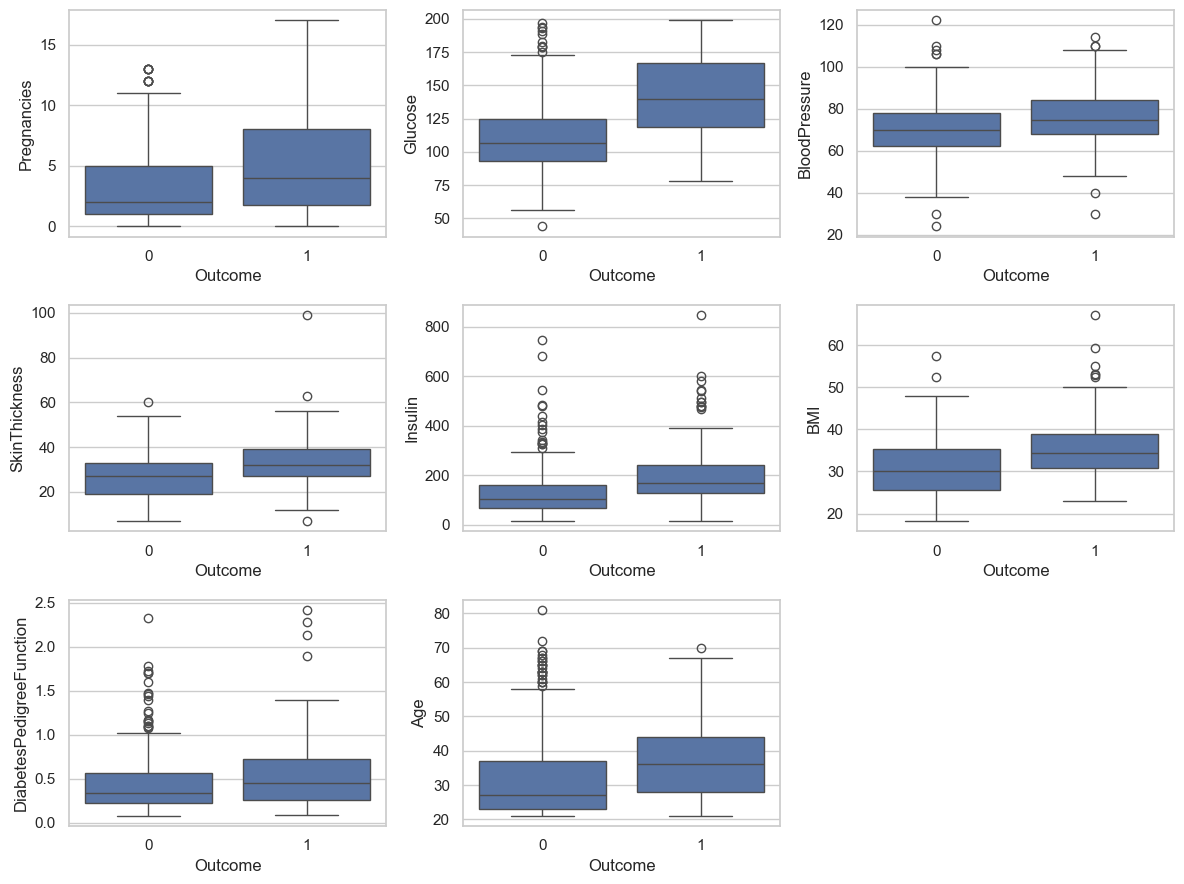

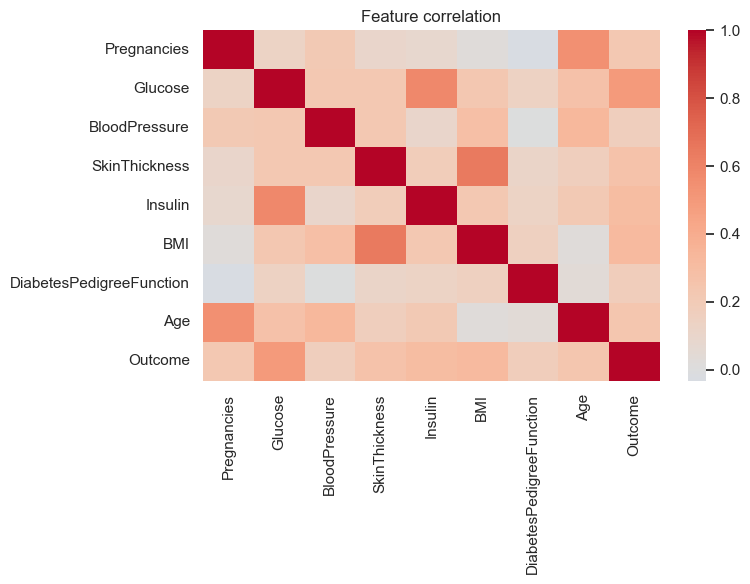

In [4]:
df = load_data(DATA_PATH)
print("Shape:", df.shape)
print(df.head(5))

zero_counts = {}
for col in ZERO_AS_MISSING:
    if col in df.columns:
        zero_counts[col] = int((df[col] == 0).sum())
if zero_counts:
    print("Zero counts (treated as missing):", zero_counts)

df = replace_zeros_with_nan(df, ZERO_AS_MISSING)
missing = df.isna().sum()
print("Missing values after replacement:\n", missing[missing > 0])

plot_basic_eda(df, TARGET_COL)


In [5]:
if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

feature_cols = [c for c in df.columns if c != TARGET_COL]
x = df[feature_cols]
y = df[TARGET_COL]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)


In [6]:
models = {
    "LogisticRegression": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "RandomForest": (
        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"),
        False,
    ),
    "GradientBoosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "SVM": (SVC(kernel="rbf", probability=True, class_weight="balanced"), True),
    "KNN": (KNeighborsClassifier(n_neighbors=15), True),
}

results = []
for name, (model, scale) in models.items():
    pipeline = build_pipeline(model, scale)
    cross_validate_auc(name, pipeline, x, y)
    metrics = evaluate_model(name, pipeline, x_train, x_test, y_train, y_test)
    results.append(metrics)


LogisticRegression CV AUC: mean=0.8362 std=0.0201

== LogisticRegression ==
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

{'model': 'LogisticRegression', 'accuracy': 0.7337662337662337, 'precision': 0.6031746031746031, 'recall': 0.7037037037037037, 'f1': 0.6495726495726496, 'roc_auc': 0.8125925925925926}
RandomForest CV AUC: mean=0.8248 std=0.0186

== RandomForest ==
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154

{'model': 'RandomFores

In [7]:
best = None
for item in results:
    if "roc_auc" not in item:
        continue
    if best is None or item["roc_auc"] > best["roc_auc"]:
        best = item

if best:
    print(f"\nBest model by test ROC AUC: {best['model']} ({best['roc_auc']:.4f})")



Best model by test ROC AUC: GradientBoosting (0.8315)
